In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import *

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
data = load_all()
trials = list(iter_trials(data))

In [4]:
# Drop a few input/output variables that are tautological — agents can't
# really get them wrong (every trial × sub-question rated as a perfect
# "match"). Including them would just inflate the Variables block in the
# summary visualization without showing any meaningful variation.
#   sosa2024 Q3  input  — Time from start of trial in seconds
#   sosa2024 Q4  input  — Environment type
#   sosa2024 Q5  input  — Trial number
#   hasnain2024 Q4 output — context
#   hasnain2024 Q5 output — outcome
TAUTOLOGICAL = {
    "sosa2024":    ["3", "4", "5"],
    "hasnain2024": ["4", "5"],
}
for ds, qs in TAUTOLOGICAL.items():
    for q in qs:
        data[ds].pop(q, None)

# Re-derive the flat trial list so downstream cells see the pruned data.
trials = list(iter_trials(data))

### Summary Analysis

In [5]:
# Categorization, layout, and plotting helpers all live in utils.py
# (already brought in via `from utils import *` at the top of the notebook):
#   categorize, collect_rows         — sub-question taxonomy
#   compute_layout                   — shared y-positions across columns
#   draw_dataset_column              — one rating-square column per dataset
#   draw_label_column                — left-margin axes with row/category labels
#   CATEGORY_ORDER, SUBTYPE_ORDER    — fixed top-down section ordering
#   RATING_COLORS                    — rating → color
#
# Edit utils.py to change the taxonomy or visual defaults; the cells below
# only deal with figure layout (figsize, gaps, label positions).

In [10]:
import pandas as pd

# Which rater's ratings drive everything below: the per-trial scores, the
# multi-dataset visualization, the End-to-End rows, and the Average column.
# Options: "best_rating" (combined best per trial — default), "human",
# "claude", or "codex". Set this once at the top; both this cell and the
# multi-dataset cell honor it.
RATING_FIELD = "codex"

# Per-trial overall score: collapse each (dataset, agent, trial)'s ratings
# across all non-Code-Efficiency questions into a coarse bucket determined
# by the worst rating in that set. See `compute_trial_scores` in utils.py.
trial_scores = pd.DataFrame(compute_trial_scores(data, rating_field=RATING_FIELD))
trial_scores

,dataset,agent,trial,n_questions,n_ok,min_rating,bucket
0,allen2p,claude-code,1,25,10,-2.0,has incorrect
1,allen2p,claude-code,2,25,10,-2.0,has incorrect
2,allen2p,claude-code,3,25,7,-2.0,has incorrect
3,allen2p,codex,1,20,6,-2.0,has incorrect
4,allen2p,codex,2,25,7,-2.0,has incorrect
5,allen2p,codex,3,25,5,-2.0,has incorrect
6,chen2024,claude-code,1,20,15,-1.0,≥ concerning
7,chen2024,claude-code,2,20,15,-2.0,has incorrect
8,chen2024,claude-code,3,20,17,-1.0,≥ concerning
9,chen2024,codex,1,20,16,-1.0,≥ concerning


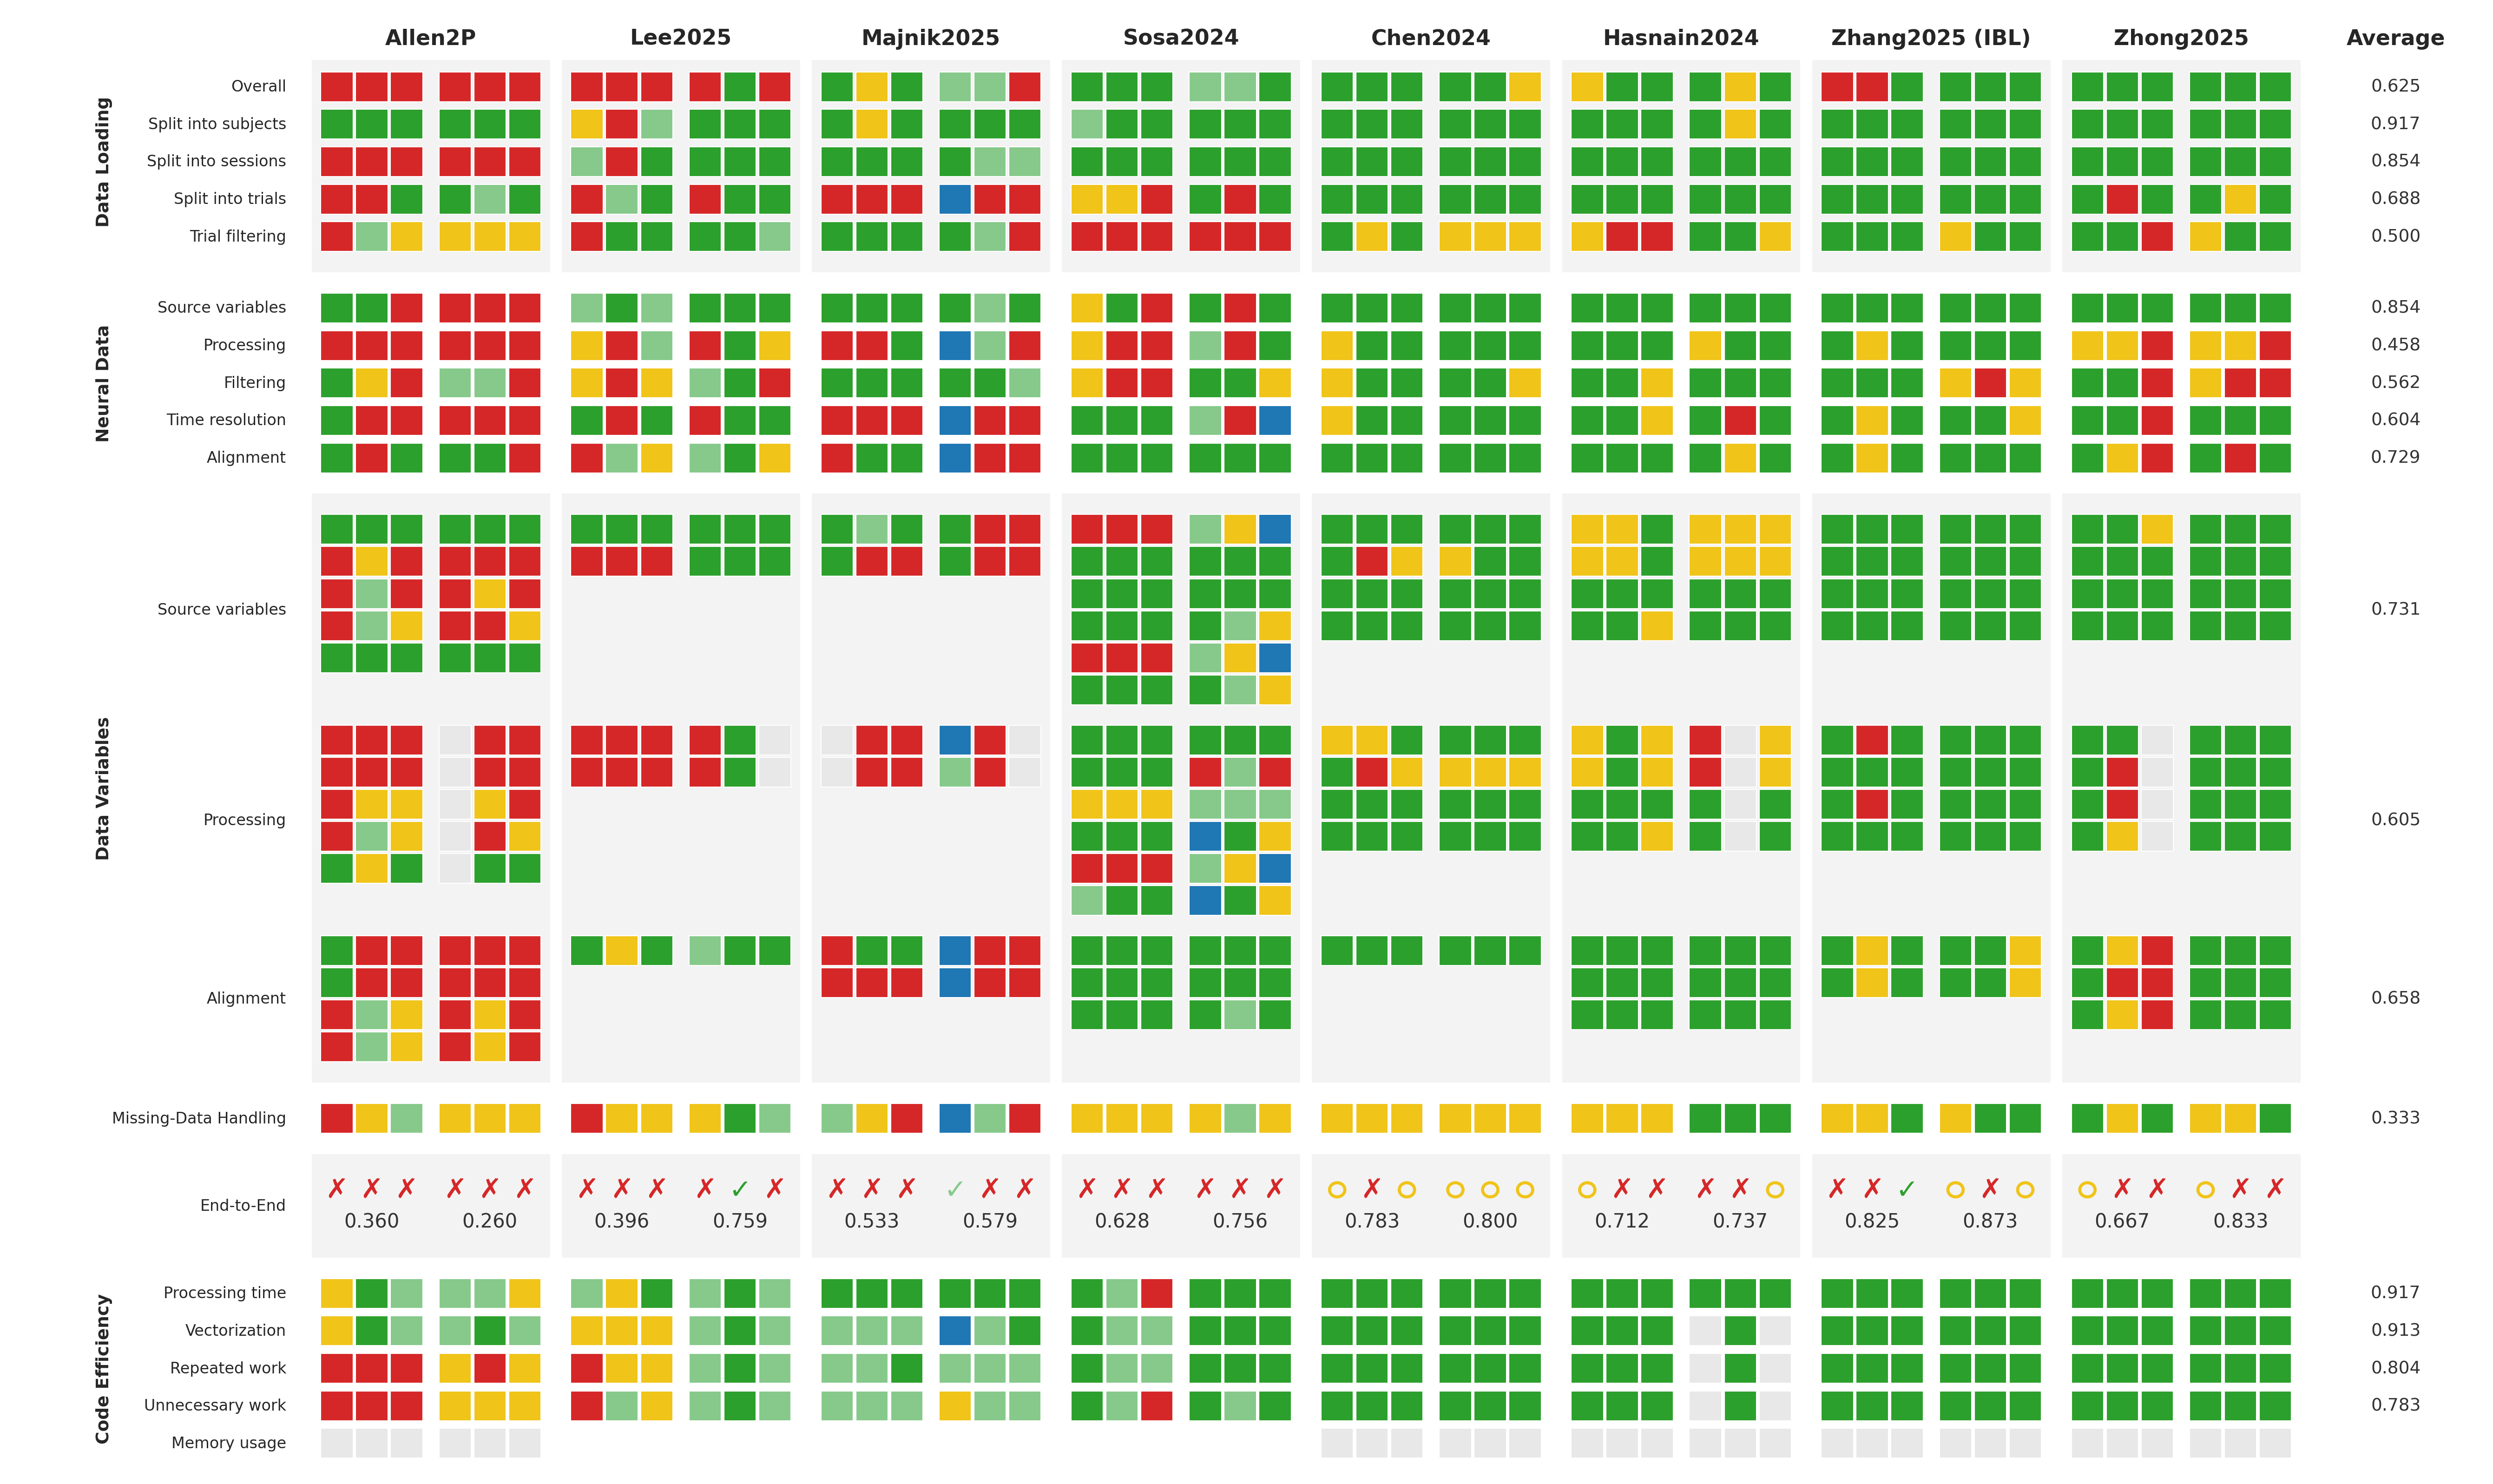

In [11]:
# Custom column order — supervised-behavior datasets first, then the rest.
DATASET_ORDER = [
    "allen2p", "lee2025", "majnik2025", "sosa2024",
    "chen2024", "hasnain2024", "zhang2025", "zhong2025",
]
datasets_sorted = [ds for ds in DATASET_ORDER if ds in data]
n = len(datasets_sorted)

# For each dataset: per-question rows + the two End-to-End summary rows
# (worst-rating symbols + per-agent mean n_ok/n_questions text), spliced
# in just before the Code Efficiency block. RATING_FIELD comes from the
# previous cell — change it there to switch rater (best/human/claude/codex).
all_rows = [
    insert_end_to_end(
        collect_rows(data[ds], rating_field=RATING_FIELD),
        end_to_end_rows(ds, trial_scores),
    )
    for ds in datasets_sorted
]

# Per-(category, subtype) grand-average proportion of correct (≥ ok) ratings,
# pooled across all datasets, agents, trials, and (for Data Variables)
# variables. End-to-End is excluded by default — see `compute_subtype_summary`
# in utils.py.
summary = compute_subtype_summary(all_rows)

# Display-only label overrides for column titles (the underlying dataset keys
# in `data` are unchanged).
DISPLAY_NAME = {
    "allen2p":   "Allen2P",
    "zhang2025": "Zhang2025 (IBL)",
}
def display_name(ds):
    return DISPLAY_NAME.get(ds, ds[:1].upper() + ds[1:])

# Single shared layout — every column places its rows at the same y for any
# given (category, subtype, slot). Subtype slots are sized to the dataset that
# has the most rows in that slot; shorter datasets leave gaps.
# Tight subtype gap for the small categories (Data Loading, Neural Data, Code
# Efficiency) but a larger gap inside the Data Variables block where stacked
# sub-types (Source variables / Processing / Alignment) need breathing room.
layout = compute_layout(all_rows, subtype_gap={"Data Variables": 0.5, "*": 0.15})

# Layout: 1 label axes + n IDENTICAL data axes + 1 summary axes. We drop
# aspect="equal" on the data axes so each one fills its gridspec slot
# vertically; we instead size the figure so the natural axes box already
# matches the data range ratio, accounting for figure margins and subplot
# spacing so cells stay square.
data_y_range = layout["y_top"] - layout["y_bot"] + 1.6 + 0.3   # incl. title pad
data_x_range = 6 * layout["square"] + 0.35 + 0.4               # 6 cells + agent gap + pad
left, right, top, bottom, wspace = 0.02, 0.99, 0.97, 0.02, 0.05
label_w_ratio = 1.2                                            # label axes / data axes width
summary_w_ratio = 0.7                                          # summary axes / data axes width
cell_aspect_fudge = 1.08                                       # >1 widens cells (perceptually squarer)
cell_size_frac = 0.925                                         # <1 shrinks each cell to leave a gap

fig_h_in = 11.0
axes_h_in = fig_h_in * (top - bottom)                          # phys h of one axes
data_axes_w = axes_h_in / (data_y_range / data_x_range) * cell_aspect_fudge
total_axes_w = (label_w_ratio + n + summary_w_ratio) * data_axes_w * (1 + wspace)
fig_w_in = total_axes_w / (right - left)

fig, axes = plt.subplots(
    1, n + 2, figsize=(fig_w_in, fig_h_in), sharey=True,
    gridspec_kw={"width_ratios": [label_w_ratio] + [1.0] * n + [summary_w_ratio]},
)
fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom, wspace=wspace)

# category_label_x bumped right so the rotated category headers sit just
# beside the subtype labels instead of all the way at the left edge.
draw_label_column(axes[0], layout, category_label_x=0.3)

for ax, ds, rows in zip(axes[1:-1], datasets_sorted, all_rows):
    draw_dataset_column(
        ax, rows, layout,
        title=display_name(ds), show_labels=False, keep_aspect=False,
        cell_size_frac=cell_size_frac,
    )

# Rightmost column: per-subtype grand-average fraction of correct ratings.
draw_summary_column(axes[-1], layout, summary, title="Average")

plt.show()

### Additional Analysis

In [ ]:
# agent performance comparsion
claude_scores = []
codex_scores = []

for dataset, qid, agent, trial, human, claude, codex, best_who, best_rating in trials:
    if agent == "claude-code":
        claude_scores.append(best_rating)

    elif agent == "codex":
        codex_scores.append(best_rating)

In [ ]:
bins = np.arange(-2, 3)  # -2, -1, 0, 1, 2

claude_counts = np.array([sum(s == b for s in claude_scores if s is not None) for b in bins])
codex_counts  = np.array([sum(s == b for s in codex_scores  if s is not None) for b in bins])

claude_counts = claude_counts / sum(claude_counts)
codex_counts  = codex_counts  / sum(codex_counts)

width = 0.4
plt.bar(bins - width / 2, claude_counts, width, label="Claude-Code", color="C0", alpha=0.75)
plt.bar(bins + width / 2, codex_counts,  width, label="Codex",       color="C1", alpha=0.75)

plt.xticks(bins)
plt.xlabel("Rating")
plt.ylabel("Proportion of Trials")
plt.legend()
plt.show()

In [ ]:
# trial variance analysis
questions = list(iter_questions(data))
all_diff = []
claude_diffs = []
codex_diffs = []

for q in questions:
    medium_rating = np.median(q['best_rating'])
    rating_diff = q['best_rating'] - medium_rating

    # append to all_diff
    all_diff.extend(rating_diff)

    # individual agent diff
    claude_rating = q['best_rating'][np.array(q['agents']) == "claude-code"]
    codex_rating  = q['best_rating'][np.array(q['agents']) == "codex"]

    claude_diff = claude_rating - np.median(claude_rating)
    codex_diff  = codex_rating  - np.median(codex_rating)
    claude_diffs.extend(claude_diff)
    codex_diffs.extend(codex_diff)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist(all_diff, bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Overall", color="gray", density=True)
axs[1].hist(claude_diffs, bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Claude-Code", color="C0", density=True)
axs[2].hist(codex_diffs,  bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Codex", color="C1", density=True)

for ax in axs:
    ax.set_xlabel("Delta Median")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.9)
    ax.legend(loc="upper left")

plt.show()

In [ ]:
# trial variance analysis
questions = list(iter_questions(data))
all_diff = []
claude_diffs = []
codex_diffs = []

for q in questions:
    max_rating = np.max(q['best_rating'])
    rating_diff = q['best_rating'] - max_rating

    # append to all_diff
    all_diff.extend(rating_diff)

    # individual agent diff
    claude_rating = q['best_rating'][np.array(q['agents']) == "claude-code"]
    codex_rating  = q['best_rating'][np.array(q['agents']) == "codex"]

    claude_diff = claude_rating - np.max(claude_rating)
    codex_diff  = codex_rating  - np.max(codex_rating)
    claude_diffs.extend(claude_diff)
    codex_diffs.extend(codex_diff)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist(all_diff, bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Overall", color="gray", density=True)
axs[1].hist(claude_diffs, bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Claude-Code", color="C0", density=True)
axs[2].hist(codex_diffs,  bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Codex", color="C1", density=True)

for ax in axs:
    ax.set_xlabel("Delta Max")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.9)
    ax.legend()

plt.show()